Используйте датасет Credit Card Default Prediction (предсказание дефолта по кредитной карте), доступный по ссылке:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Целевая переменная: default.payment.next.month (дефолт в следующем месяце).
Признаки: демографические данные, история платежей, сумма кредита и др.



In [89]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print(f"Путь к датасету: {path}")


import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            break

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Путь к датасету: /kaggle/input/default-of-credit-card-clients-dataset


Задача 1. Подготовка данных и базовое моделирование (1 балла)
- Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

- Обучите модель CatBoostClassifier с параметрами по умолчанию.

- Оцените качество модели с помощью ROC-AUC на тесте.

In [90]:
!pip -q install kagglehub catboost

In [91]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [92]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [93]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [94]:
from sklearn.model_selection import train_test_split

target = "default.payment.next.month"
print("Target column:", target)

Target column: default.payment.next.month


In [95]:
drop_cols = [target]
if "ID" in df.columns:
    drop_cols.append("ID")

In [96]:
X = df.drop(columns=drop_cols)
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((24000, 23), (6000, 23))

In [97]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_cols = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in X.columns]
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

model = CatBoostClassifier()

model.fit(
    X_train, y_train,
    cat_features=cat_idx if len(cat_idx) else None,
    verbose=False
)

proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"Test ROC-AUC: {auc:.4f}")

Test ROC-AUC: 0.7767


Задача 2. Оценка важности признаков (2 балла)
- Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

- Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

- SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

Важно! Вычисляйте важность на обучающей или валидационной выборке, но не на тестовой. Тестовая выборка используется только для финальной оценки модели.

In [98]:
from catboost import Pool

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

cat_cols = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in X_train.columns]
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]

model = CatBoostClassifier()
model.fit(
    X_fit, y_fit,
    cat_features=cat_idx if len(cat_idx) else None,
    verbose=False
)

val_pool = Pool(X_val, y_val, cat_features=cat_idx if len(cat_idx) else None, feature_names=X_val.columns.tolist())

In [99]:
imp_pvc = model.get_feature_importance(val_pool, type="PredictionValuesChange")
fi_pvc = (pd.DataFrame({"feature": X_val.columns, "importance": imp_pvc})
          .sort_values("importance", ascending=False))

fi_pvc.head(23)

,feature,importance
5,PAY_0,11.228307
0,LIMIT_BAL,8.561297
11,BILL_AMT1,7.390462
19,PAY_AMT3,5.863451
4,AGE,5.663795
22,PAY_AMT6,5.598845
17,PAY_AMT1,5.534209
18,PAY_AMT2,5.016680
20,PAY_AMT4,4.979372
12,BILL_AMT2,4.784429


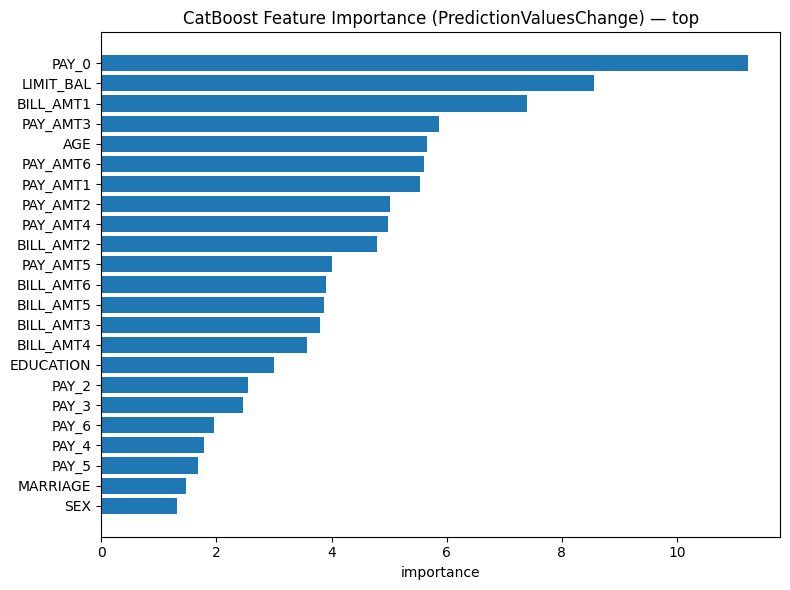

In [100]:
import matplotlib.pyplot as plt

topk = 23
plt.figure(figsize=(8, 6))
plt.barh(fi_pvc["feature"].head(topk)[::-1], fi_pvc["importance"].head(topk)[::-1])
plt.title("CatBoost Feature Importance (PredictionValuesChange) — top")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

Топ признаков: PAY_0, LIMIT_BAL, BILL_AMT1, PAY_AMT3, AGE, и т.д.

In [101]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_val, y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

fi_perm = (pd.DataFrame({
    "feature": X_val.columns,
    "mean": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("mean", ascending=False))

fi_perm.head(23)

,feature,mean,std
5,PAY_0,0.076561,0.003116
0,LIMIT_BAL,0.025788,0.002466
11,BILL_AMT1,0.013005,0.001974
18,PAY_AMT2,0.007220,0.001010
7,PAY_3,0.006642,0.001046
20,PAY_AMT4,0.006216,0.001163
19,PAY_AMT3,0.005728,0.001549
6,PAY_2,0.005289,0.001064
12,BILL_AMT2,0.005190,0.001131
13,BILL_AMT3,0.004802,0.001276


/tmp/ipython-input-2614021959.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=labels)


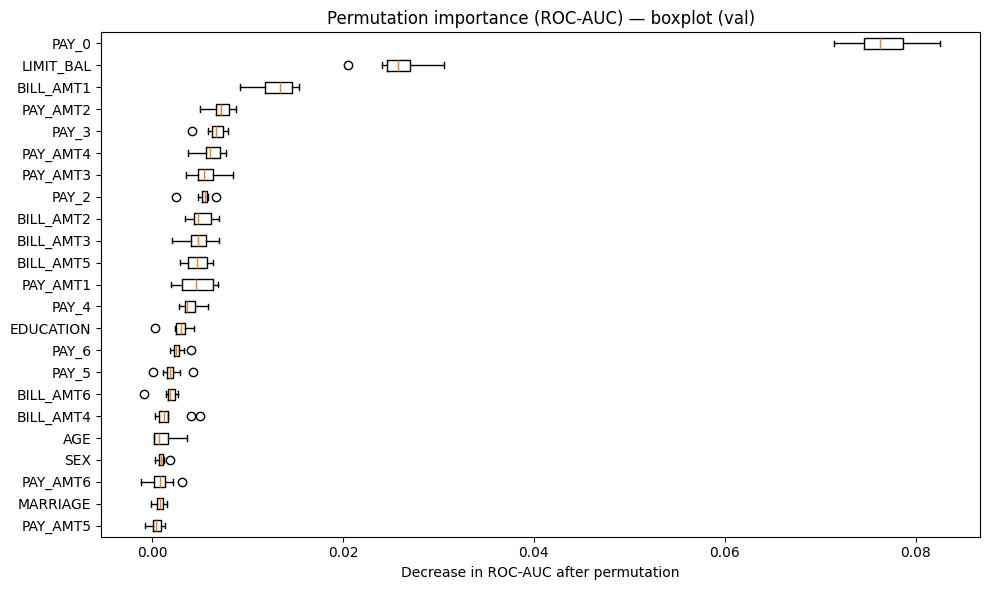

In [102]:
import numpy as np

topk = 23
idx = np.argsort(perm.importances_mean)[-topk:]
data = perm.importances[idx].T
labels = X_val.columns[idx]

plt.figure(figsize=(10, 6))
plt.boxplot(data, vert=False, labels=labels)
plt.title("Permutation importance (ROC-AUC) — boxplot (val)")
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.tight_layout()
plt.show()

PAY_0: mean = 0.0766, std = 0.0031 => самый устойчивый признак (перемешали — AUC падает сильнее всего).

LIMIT_BAL: mean = 0.0258.

BILL_AMT1: mean = 0.0130.

Дальше уже заметно меньше (это видно и на boxplot: коробки близки к нулю)

Трактовка mean/std:

mean - среднее падение ROC-AUC при перемешивании признака

std - насколько шумное измерение: чем меньше, тем стабильнее вывод.

In [103]:
!pip -q install shap
import shap

shap.initjs()

shap_vals_full = model.get_feature_importance(val_pool, type="ShapValues")
shap_values = shap_vals_full[:, :-1]
base_values = shap_vals_full[:, -1]

X_val_np = X_val

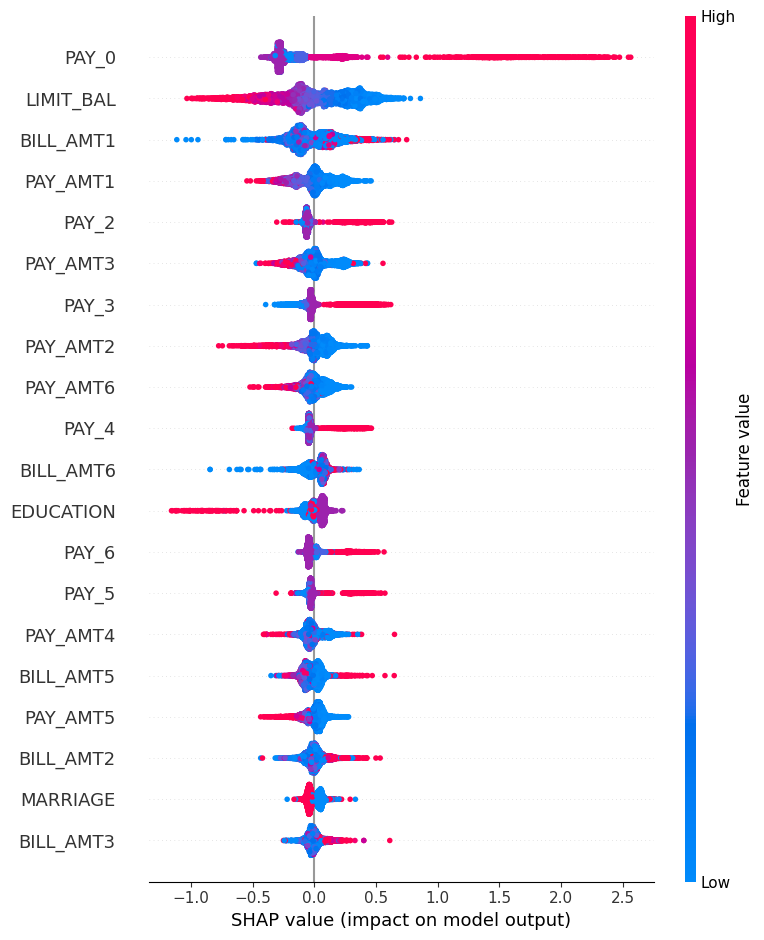

In [104]:
shap.summary_plot(shap_values, X_val_np)

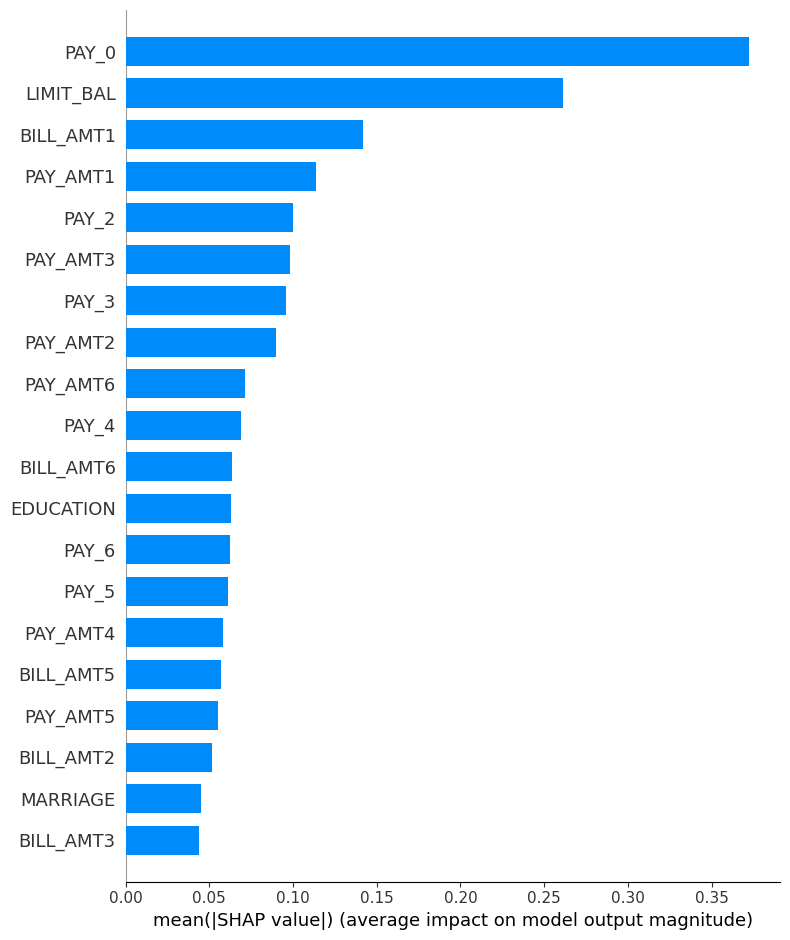

In [105]:
shap.summary_plot(shap_values, X_val_np, plot_type="bar")

In [106]:
i = 0
fp = shap.force_plot(base_values[i], shap_values[i, :], X_val_np.iloc[i, :])
fp

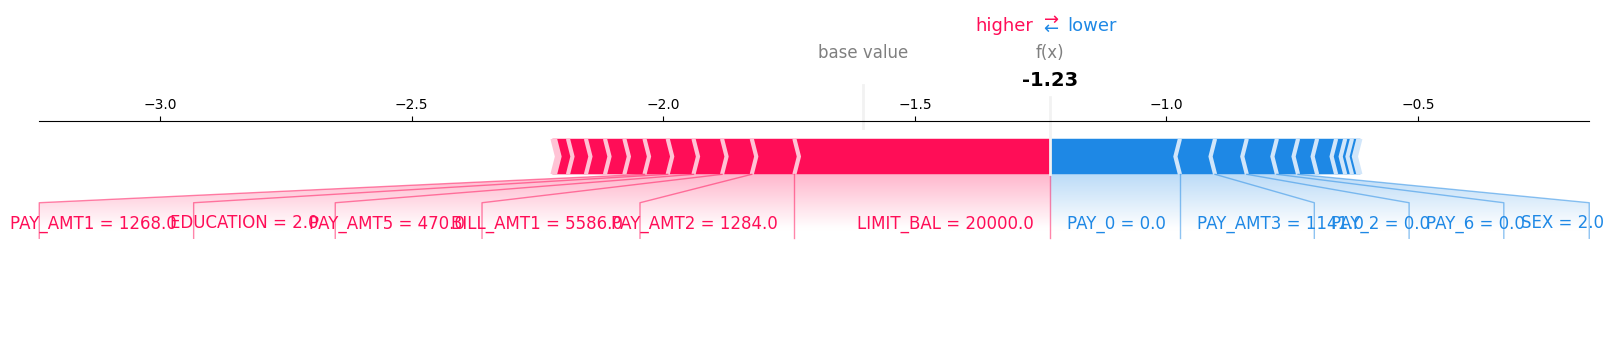

In [107]:
shap.force_plot(base_values[i], shap_values[i, :], X_val_np.iloc[i, :], matplotlib=True)

Модель стартует от базового уровня риска(base value).

Признаки LIMIT_BAL, BILL_AMT1, PAY_AMT2 и т.д. дали вклад (красные) => сдвинули скор в сторону дефолта.

Признаки PAY_0, PAY_AMT3, PAY_2, PAY_6, SEX дали вклад (синие) => сдвинули скор в сторону “не дефолт”.

Итоговый скор f(x)=-1.23 означает пониженную вероятность дефолта (примерно 0.23).

Задача 3. Выводы (1 балла)
- Сравните топ-5 важных признаков по каждому методу.

- Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

- Объясните, почему методы могут давать разные результаты.

In [108]:
neg_perm = fi_perm[fi_perm["mean"] < 0].sort_values("mean")
neg_perm

,feature,mean,std


Ответ:

1.

CatBoost (PredictionValuesChange), топ-5: PAY_0, LIMIT_BAL, BILL_AMT1, PAY_AMT3, AGE.

Permutation Importance (ROC-AUC на val), топ-5: PAY_0, LIMIT_BAL, BILL_AMT1, PAY_AMT2, PAY_3.

SHAP (mean(|SHAP|)), топ-5: PAY_0, LIMIT_BAL, BILL_AMT1, PAY_AMT1, PAY_2.

2.

Важны во всех трёх методах: PAY_0, LIMIT_BAL, BILL_AMT1 — в топе у всех трёх.

Важны только в одном методе: только CatBoost - AGE; только Permutation - PAY_3; только SHAP - PAY_AMT1, PAY_2.

Признаки с отрицательной важностью в Permutation Importance: ни у одного признака permutation importance не получилось отрицательным: при перемешивании любого признака ROC-AUC не увеличивался (в среднем). То есть “шумных” признаков, которые мешали модели, по этой оценке нет.

3.

1) Разный смысл важности.

CatBoost PredictionValuesChange — внутримодельная мера: насколько признак меняет предсказания в деревьях.

Permutation — внешняя мера: насколько падает метрика (ROC-AUC), если признак “сломать”.

SHAP — локально-глобальная интерпретация: вклад признака в предсказание, агрегированный по объектам.

2) Коррелирующие признаки делят важность между собой.

Например, PAY_AMT*, BILL_AMT*, PAY_* частично описывают одно и то же поведение клиента.
Тогда  Permutation может показать низкую важность у одного признака (потому что его заменяет другой), SHAP/CatBoost могут распределить вклад иначе.

3) Нелинейности и взаимодействия. В деревьях признаки могут быть важны только в комбинации (например, высокий BILL + плохой PAY статус). Permutation перемешивает один признак и может ломать взаимодействие сильнее/слабее, чем ожидается.

Задача 4. Отбор признаков (2 балла)

- Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

- Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

- Можно ли сократить количество признаков без потери качества?

In [109]:
RANDOM_COL = "RANDOM_NOISE"

X_fit_r = X_fit.copy()
X_val_r = X_val.copy()

rng = np.random.RandomState(42)
X_fit_r[RANDOM_COL] = rng.normal(size=len(X_fit_r))
X_val_r[RANDOM_COL] = rng.normal(size=len(X_val_r))

cat_cols = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in X_fit_r.columns]
cat_idx_r = [X_fit_r.columns.get_loc(c) for c in cat_cols]

model_r = CatBoostClassifier()
model_r.fit(X_fit_r, y_fit, cat_features=cat_idx_r if len(cat_idx_r) else None, verbose=False)

perm_r = permutation_importance(
    model_r, X_val_r, y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

fi_perm_r = pd.DataFrame({
    "feature": X_val_r.columns,
    "mean": perm_r.importances_mean,
    "std": perm_r.importances_std
}).sort_values("mean", ascending=False)

fi_perm_r.head(10), fi_perm_r[fi_perm_r["feature"] == RANDOM_COL]


(      feature      mean       std
 5       PAY_0  0.072351  0.003413
 0   LIMIT_BAL  0.024414  0.003210
 11  BILL_AMT1  0.011731  0.002307
 18   PAY_AMT2  0.007405  0.001086
 7       PAY_3  0.006780  0.001177
 6       PAY_2  0.005757  0.001124
 13  BILL_AMT3  0.004805  0.001516
 19   PAY_AMT3  0.004667  0.001154
 12  BILL_AMT2  0.004010  0.001038
 15  BILL_AMT5  0.003965  0.001428,
          feature     mean       std
 23  RANDOM_NOISE -0.00224  0.000699)

In [110]:
rand_mean = fi_perm_r.loc[fi_perm_r["feature"] == RANDOM_COL, "mean"].iloc[0]
rand_std  = fi_perm_r.loc[fi_perm_r["feature"] == RANDOM_COL, "std"].iloc[0]

threshold = max(0.0, rand_mean + rand_std)   # можно +2*rand_std для жестче
selected = fi_perm_r.loc[(fi_perm_r["mean"] > threshold) & (fi_perm_r["feature"] != RANDOM_COL), "feature"].tolist()

print("rand_mean, rand_std:", rand_mean, rand_std)
print("threshold:", threshold)
print("Selected:", len(selected), "of", X_fit.shape[1])

rand_mean, rand_std: -0.002240096912291345 0.0006985929365663842
threshold: 0.0
Selected: 22 of 23


In [111]:
base_model = CatBoostClassifier()
base_model.fit(X_fit, y_fit, cat_features=cat_idx if len(cat_idx) else None, verbose=False)
base_auc = roc_auc_score(y_val, base_model.predict_proba(X_val)[:, 1])

X_fit_sel = X_fit[selected]
X_val_sel = X_val[selected]

cat_cols_sel = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in X_fit_sel.columns]
cat_idx_sel  = [X_fit_sel.columns.get_loc(c) for c in cat_cols_sel]

sel_model = CatBoostClassifier()
sel_model.fit(X_fit_sel, y_fit, cat_features=cat_idx_sel if len(cat_idx_sel) else None, verbose=False)
sel_auc = roc_auc_score(y_val, sel_model.predict_proba(X_val_sel)[:, 1])

print(f"Baseline ROC-AUC (val): {base_auc:.4f}")
print(f"Reduced  ROC-AUC (val): {sel_auc:.4f}")
print(f"ΔAUC: {sel_auc - base_auc:+.4f}")


Baseline ROC-AUC (val): 0.7819
Reduced  ROC-AUC (val): 0.7835
ΔAUC: +0.0016


In [112]:
test_auc_base = roc_auc_score(y_test, base_model.predict_proba(X_test)[:, 1])
test_auc_sel  = roc_auc_score(y_test, sel_model.predict_proba(X_test[selected])[:, 1])

print(f"Baseline ROC-AUC (test): {test_auc_base:.4f}")
print(f"Reduced  ROC-AUC (test): {test_auc_sel:.4f}")


Baseline ROC-AUC (test): 0.7746
Reduced  ROC-AUC (test): 0.7782


Ответ:

Selected: 22 of 23 => выкинули ровно 1 признак (тот, у которого permutation mean <= 0; обычно это самый шумный/бесполезный в данном прогоне).

Сокращение не ухудшило качество и даже слегка улучшило(убрали шумный признак).


Для отбора признаков был использован порог важности на основе случайного признака RANDOM_NOISE. Поскольку permutation importance случайного признака оказалась отрицательной, порог был взят как threshold = max(0, mean(RANDOM_NOISE) + std(RANDOM_NOISE)), что дало threshold = 0. Далее были оставлены признаки с permutation importance mean > 0 (случайный признак исключён). В результате осталось 22 из 23 исходных признаков.
Качество модели на сокращённом наборе не ухудшилось: ROC-AUC на валидации вырос с 0.7819 до 0.7835 (Δ=+0.0016), на тесте — с 0.7746 до 0.7782. Следовательно, частично сократить набор признаков можно без потери качества (в данном эксперименте — даже с небольшим улучшением), поскольку удалённый признак не добавлял полезной информации и, вероятно, вносил шум.

In [113]:
removed = sorted(set(X_fit.columns) - set(selected))
removed

['PAY_AMT5']

Удалили признак PAY_AMT5.


Задача 5. Анализ с добавленными случайными признаками (4 балла)

- Добавьте 10 случайных нормально распределенных признаков в датасет.

- Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

- Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

- Для каждого порога обучите модель и оцените ROC-AUC на тесте.

- Постройте график зависимости ROC-AUC от количества удаленных признаков.

- Проанализируйте, как изменяется качество модели при удалении разных долей признаков.


In [114]:
noise_cols = [f"NOISE_{i}" for i in range(10)]
rng = np.random.RandomState(42)

def add_noise(X, rng):
    Xn = X.copy()
    for c in noise_cols:
        Xn[c] = rng.normal(size=len(Xn))
    return Xn

X_fit_n = add_noise(X_fit, rng)
X_val_n = add_noise(X_val, rng)
X_test_n = add_noise(X_test, rng)

cat_cols = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in X_fit_n.columns]
cat_idx_n = [X_fit_n.columns.get_loc(c) for c in cat_cols]

len(X_fit.columns), len(X_fit_n.columns)


(23, 33)

In [115]:
model_n = CatBoostClassifier()
model_n.fit(X_fit_n, y_fit, cat_features=cat_idx_n if len(cat_idx_n) else None, verbose=False)

val_pool_n = Pool(X_val_n, y_val, cat_features=cat_idx_n if len(cat_idx_n) else None, feature_names=X_val_n.columns.tolist())

In [116]:
imp_pvc_n = model_n.get_feature_importance(val_pool_n, type="PredictionValuesChange")
fi_pvc_n = pd.DataFrame({"feature": X_val_n.columns, "importance": imp_pvc_n}).sort_values("importance", ascending=False)

fi_pvc_n[fi_pvc_n["feature"].isin(noise_cols)].head(10)

,feature,importance
24,NOISE_1,4.520229
26,NOISE_3,4.493198
32,NOISE_9,4.366656
30,NOISE_7,4.167772
28,NOISE_5,4.087246
31,NOISE_8,4.009635
29,NOISE_6,3.735149
25,NOISE_2,3.726558
23,NOISE_0,3.722826
27,NOISE_4,3.446878


In [117]:
perm_n = permutation_importance(
    model_n, X_val_n, y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

fi_perm_n = pd.DataFrame({
    "feature": X_val_n.columns,
    "mean": perm_n.importances_mean,
    "std": perm_n.importances_std
}).sort_values("mean", ascending=False)

fi_perm_n.head(10), fi_perm_n[fi_perm_n["feature"].isin(noise_cols)].sort_values("mean", ascending=False)


(      feature      mean       std
 5       PAY_0  0.076880  0.003147
 0   LIMIT_BAL  0.020566  0.002089
 11  BILL_AMT1  0.009972  0.002358
 7       PAY_3  0.008225  0.001249
 18   PAY_AMT2  0.006121  0.000782
 6       PAY_2  0.005584  0.001089
 19   PAY_AMT3  0.004113  0.001333
 17   PAY_AMT1  0.004000  0.001400
 8       PAY_4  0.003490  0.000774
 10      PAY_6  0.002803  0.000635,
     feature      mean       std
 24  NOISE_1  0.001721  0.001003
 29  NOISE_6  0.001339  0.000512
 27  NOISE_4  0.001275  0.000774
 23  NOISE_0  0.000718  0.000825
 30  NOISE_7  0.000264  0.000896
 28  NOISE_5  0.000130  0.000601
 25  NOISE_2 -0.000053  0.001153
 26  NOISE_3 -0.000315  0.000841
 31  NOISE_8 -0.000532  0.001002
 32  NOISE_9 -0.000633  0.000697)

In [118]:
shap.initjs()

shap_vals_full_n = model_n.get_feature_importance(val_pool_n, type="ShapValues")
shap_values_n = shap_vals_full_n[:, :-1]

mean_abs_shap_n = np.abs(shap_values_n).mean(axis=0)
fi_shap_n = pd.DataFrame({"feature": X_val_n.columns, "mean_abs_shap": mean_abs_shap_n}).sort_values("mean_abs_shap", ascending=False)

fi_shap_n.head(10), fi_shap_n[fi_shap_n["feature"].isin(noise_cols)].sort_values("mean_abs_shap", ascending=False)


(      feature  mean_abs_shap
 5       PAY_0       0.401267
 0   LIMIT_BAL       0.241396
 11  BILL_AMT1       0.140418
 7       PAY_3       0.117653
 17   PAY_AMT1       0.104124
 6       PAY_2       0.086398
 18   PAY_AMT2       0.081168
 19   PAY_AMT3       0.078044
 22   PAY_AMT6       0.061734
 8       PAY_4       0.060270,
     feature  mean_abs_shap
 31  NOISE_8       0.045191
 25  NOISE_2       0.043517
 29  NOISE_6       0.042626
 24  NOISE_1       0.041130
 26  NOISE_3       0.038665
 28  NOISE_5       0.036284
 32  NOISE_9       0.035229
 30  NOISE_7       0.034553
 27  NOISE_4       0.033323
 23  NOISE_0       0.030013)

In [119]:
ranked_features = fi_perm_n["feature"].tolist()

def keep_top_by_drop_frac(ranked, drop_frac):
    n_total = len(ranked)
    n_drop = int(np.floor(n_total * drop_frac))
    kept = ranked[:(n_total - n_drop)]
    return kept, n_drop

drop_fracs = [0.0, 0.25, 0.50, 0.75]
results = []

for frac in drop_fracs:
    kept, n_drop = keep_top_by_drop_frac(ranked_features, frac)

    X_fit_k = X_fit_n[kept]
    X_test_k = X_test_n[kept]

    cat_cols_k = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in X_fit_k.columns]
    cat_idx_k = [X_fit_k.columns.get_loc(c) for c in cat_cols_k]

    m = CatBoostClassifier()
    m.fit(X_fit_k, y_fit, cat_features=cat_idx_k if len(cat_idx_k) else None, verbose=False)

    test_auc = roc_auc_score(y_test, m.predict_proba(X_test_k)[:, 1])

    results.append({
        "drop_frac": frac,
        "dropped": n_drop,
        "kept": len(kept),
        "test_roc_auc": test_auc
    })

res_df = pd.DataFrame(results).sort_values("drop_frac")
res_df


,drop_frac,dropped,kept,test_roc_auc
0,0.00,0,33,0.774434
1,0.25,8,25,0.772363
2,0.50,16,17,0.774799
3,0.75,24,9,0.769246


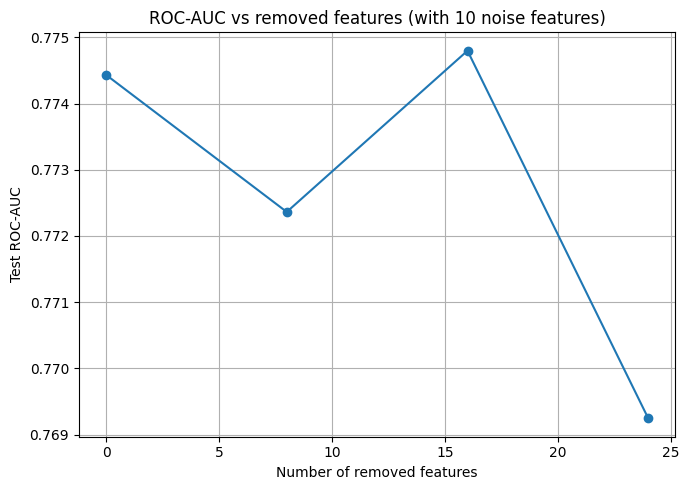

In [120]:
plt.figure(figsize=(7,5))
plt.plot(res_df["dropped"], res_df["test_roc_auc"], marker="o")
plt.xlabel("Number of removed features")
plt.ylabel("Test ROC-AUC")
plt.title("ROC-AUC vs removed features (with 10 noise features)")
plt.grid(True)
plt.tight_layout()
plt.show()

CatBoost PredictionValuesChange (PVC):

все NOISE_* получили большую важность (около 3.4–4.5) и показаны как значимые - эффект внутримодельной важности: деревья могут использовать шумовые признаки для мелких разбиений (особенно когда есть много степеней свободы); PVC измеряет изменение предсказаний внутри модели, а не падение качества на метрике; поэтому шум иногда получает заметную важность, даже если он не улучшает обобщение.

Permutation importance (ROC-AUC):

у шумов важность маленькая, часть даже отрицательная(перемешивание этого шума слегка улучшает AUC).

SHAP (mean(|SHAP|)):

SHAP тоже дал шумам не нулевую важность (mean(|SHAP|) ~ 0.03–0.045); SHAP показывает, как модель использует признак, а не насколько он нужен для качества.


Результаты:

0% удалено (0 фич): AUC 0.7744

25% удалено (8 фич): AUC 0.7724 (чуть хуже)

50% удалено (16 фич): AUC 0.7748 (чуть лучше базовой — лучший результат)

75% удалено (24 фич): AUC 0.7692 (заметно хуже)